In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df.columns


Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv("sales.csv", encoding='latin1')

# Check columns
print(df.columns)

# Convert date column (FIXED ✅)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Drop missing dates
df = df.dropna(subset=['Order_Date'])

# Create time features
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year

# Basic cleaning
df.drop_duplicates(inplace=True)
df['Sales'] = df['Sales'].fillna(0)

# AOV (Average Order Value)
aov = df['Sales'].sum() / df['Order_ID'].nunique()

print("AOV:", aov)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')
AOV: 441.7028473924051


In [9]:
print("Total Sales:", df['Sales'].sum())

Total Sales: 872363.1236


In [10]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       271156.6335
East       246227.6310
Central    208805.0696
South      146173.7895
Name: Sales, dtype: float64


In [11]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

Product_Name
Canon imageCLASS 2200 Advanced Copier                            17499.9500
Lexmark MX611dhe Monochrome Laser Printer                        11219.9340
HP Designjet T520 Inkjet Large Format Printer - 24 Color          8749.9500
GBC DocuBind TL300 Electric Binding System                        8521.4050
Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish     8298.8316
Hewlett Packard LaserJet 3310 Copier                              8159.8640
Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back       8148.9320
Cubify CubeX 3D Printer Triple Head Print                         7999.9800
Zebra ZM400 Thermal Label Printer                                 6965.7000
HON 5400 Series Task Chairs for Big and Tall                      6589.2120
Name: Sales, dtype: float64


In [12]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
1      90957.9824
2     103951.1600
3      71788.6906
4      65094.9490
5      64277.0788
6      51099.1360
7      62393.9465
8     100560.3526
9      66582.3650
10     62563.7830
11     68274.3135
12     64819.3662
Name: Sales, dtype: float64


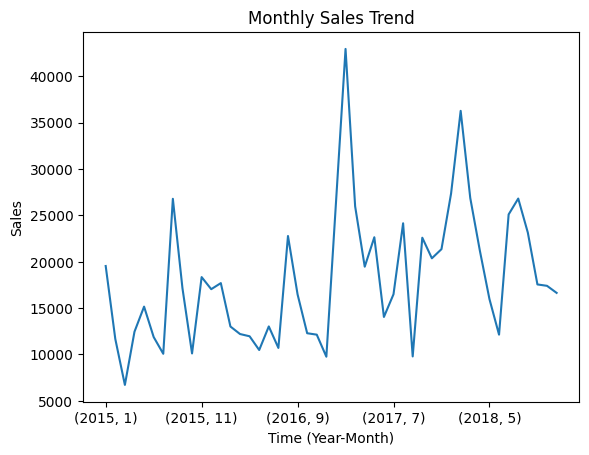

In [13]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby(['Year','Month'])['Sales'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Time (Year-Month)")
plt.ylabel("Sales")
plt.show()

💡 Insight to Write:

Identify peak months

Detect seasonality patterns

Example:

“Sales peak during Q4 indicating strong seasonal demand.”

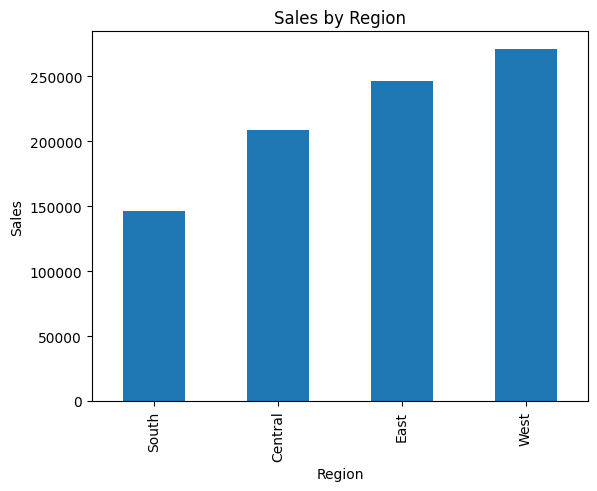

In [14]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

💡 Insight:

Which region performs best?

Which needs improvement?

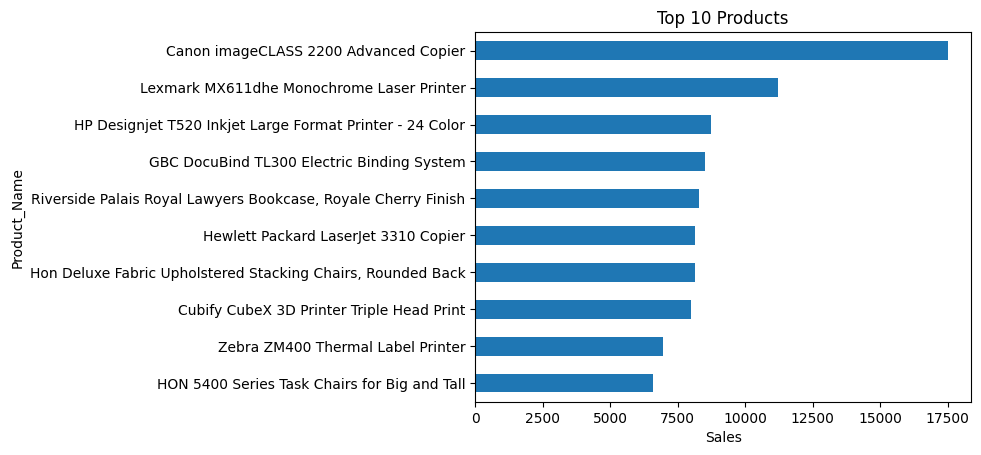

In [15]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values().tail(10)

top_products.plot(kind='barh')
plt.title("Top 10 Products")
plt.xlabel("Sales")
plt.show()

💡 Insight:

Few products drive majority revenue (Pareto effect)

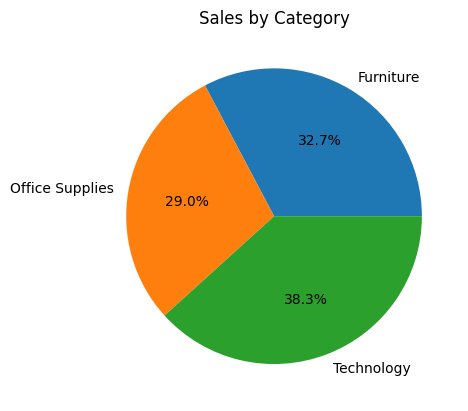

In [16]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Category")
plt.ylabel("")
plt.show()

💡 Insight:

Identify dominant product category

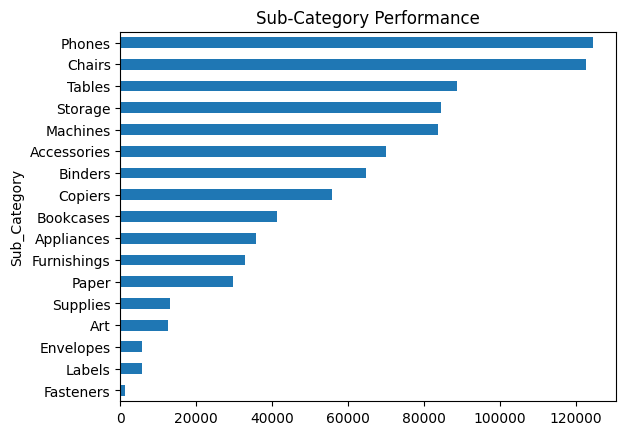

In [17]:
subcat_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values()

subcat_sales.plot(kind='barh')
plt.title("Sub-Category Performance")
plt.show()

In [18]:
df.to_csv("cleaned_sales_data.csv", index=False)